In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns

In [5]:
prsa_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.2%20numeric%20features/data/PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


In [6]:
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  object 
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  object 
dtypes: float64(7), int64(2), object(2)
memory usage: 2.9+ MB


In [8]:
prsa_data = prsa_data.drop(columns='Unnamed: 0')

In [9]:
prsa_data.describe()

,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


In [10]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


<Axes: xlabel='SO2', ylabel='Count'>

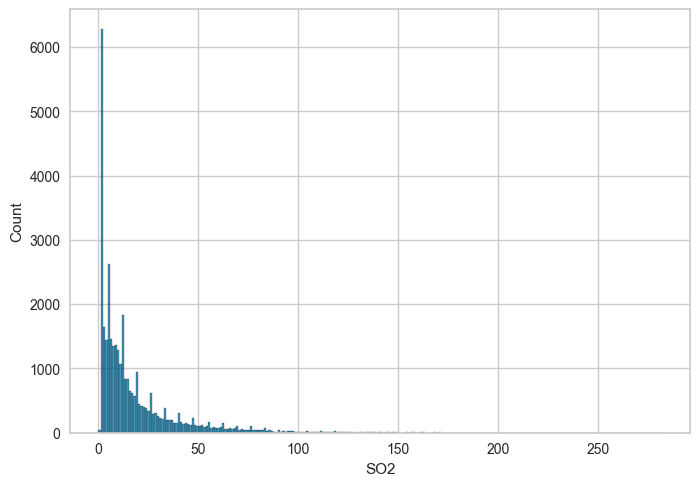

In [11]:
sns.histplot(prsa_data.SO2)

<Axes: xlabel='NO2', ylabel='Density'>

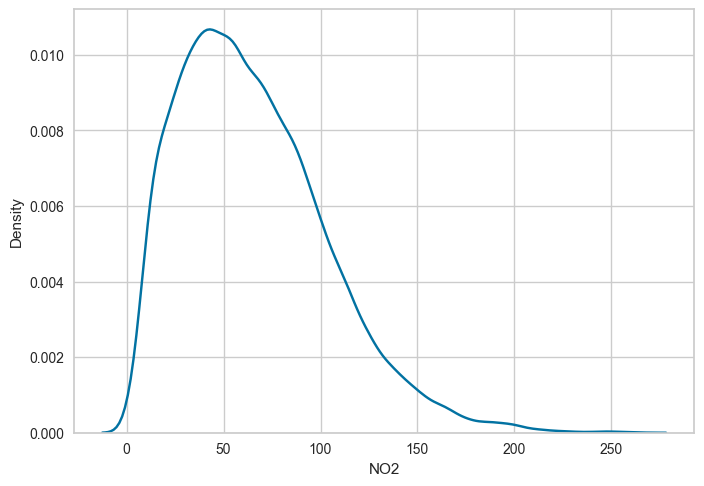

In [12]:
sns.kdeplot(prsa_data.NO2)

<Axes: xlabel='CO', ylabel='Count'>

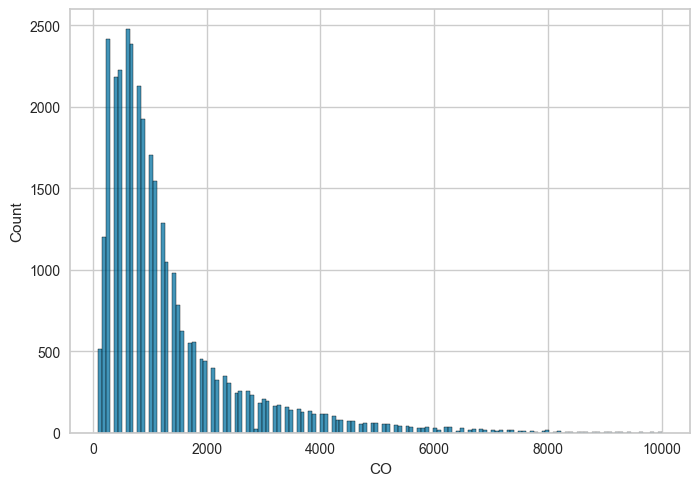

In [13]:
sns.histplot(prsa_data.CO)

<Axes: xlabel='O3', ylabel='Count'>

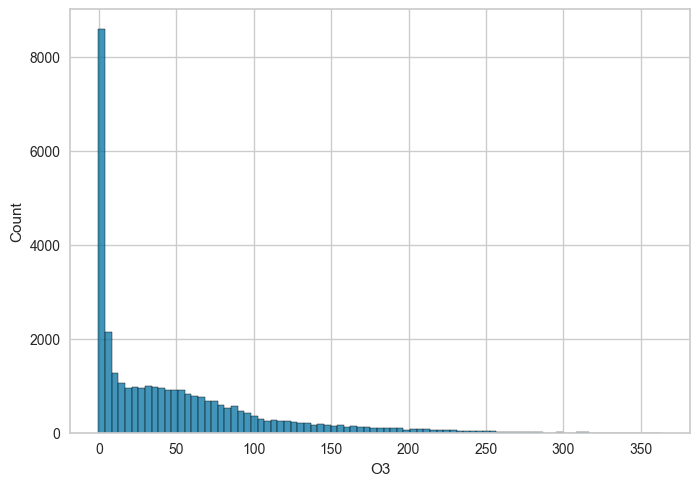

In [14]:
sns.histplot(prsa_data.O3)

In [15]:
prsa_data.RAIN[prsa_data.RAIN > 0]

267      0.1
268      0.4
269      0.1
270      0.9
271      0.9
        ... 
34891    0.2
34892    0.7
34893    0.9
34894    0.4
34895    0.2
Name: RAIN, Length: 1436, dtype: float64

In [16]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


<Axes: xlabel='SO2', ylabel='Density'>

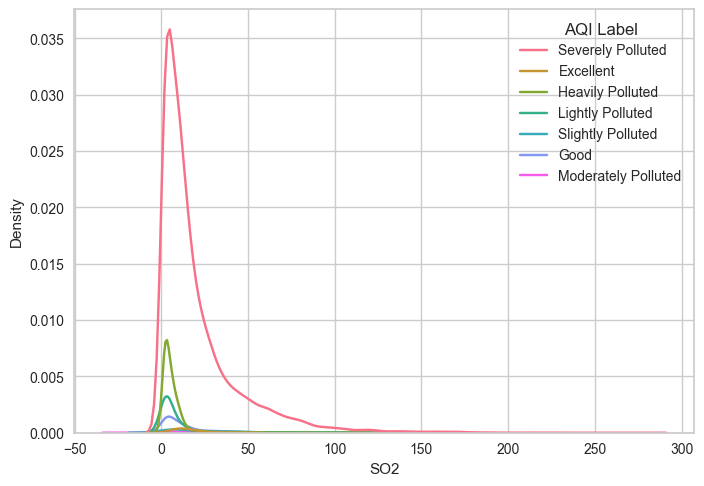

In [17]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

<Axes: xlabel='NO2', ylabel='Density'>

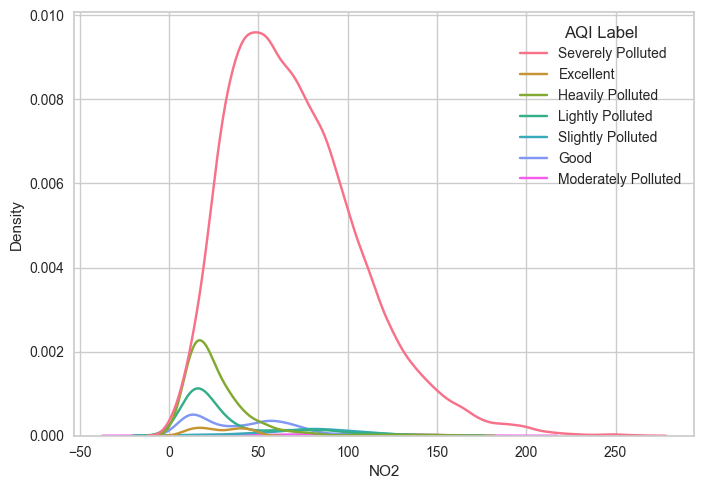

In [18]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")

График показывает распределение концентрации NO₂ для разных категорий качества воздуха (AQI): при улучшении качества воздуха значения NO₂ снижаются и становятся более сконцентрированными в узком диапазоне, тогда как при ухудшении — увеличиваются и имеют больший разброс, достигая высоких значений; при этом наблюдается частичное перекрытие распределений, что указывает на влияние и других загрязнителей при формировании итоговой категории AQI.

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_59251/491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

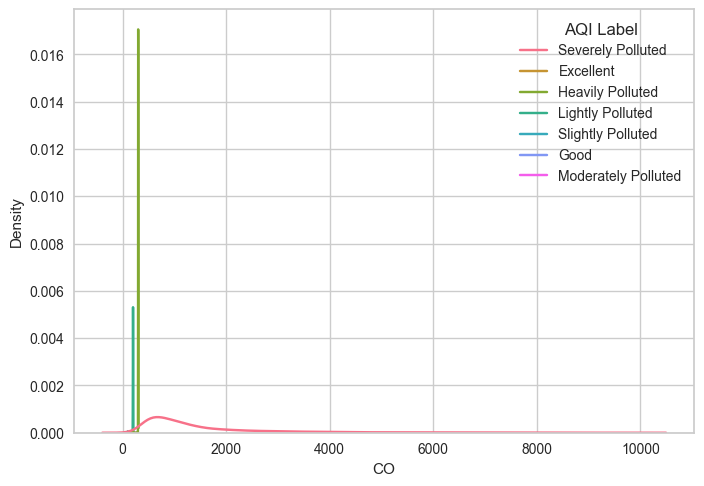

In [20]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_59251/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

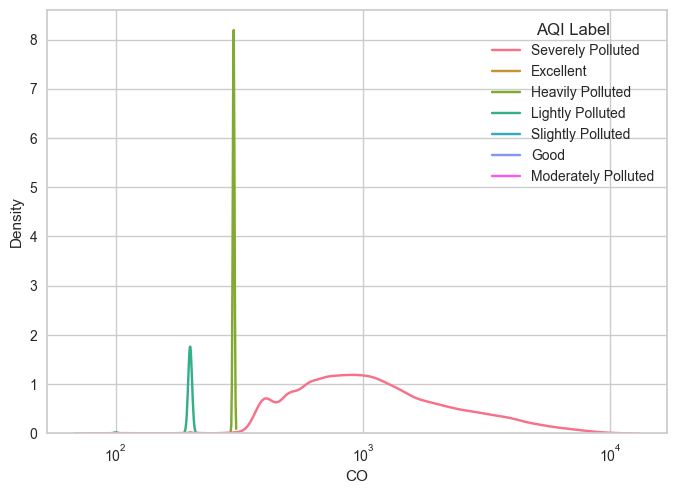

In [21]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

In [22]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']), 
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [23]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [24]:
prsa_data.PRES[prsa_data.PRES <= 992] = 992
prsa_data.PRES[prsa_data.PRES >= 1034] = 1034

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_59251/3964902396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prsa_data.PRES[prsa_data.PRES <= 992] = 992
/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_59251/3964902396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prsa_data.PRES[prsa_data.PRES >= 1034] = 1034


<Axes: xlabel='PRES', ylabel='Count'>

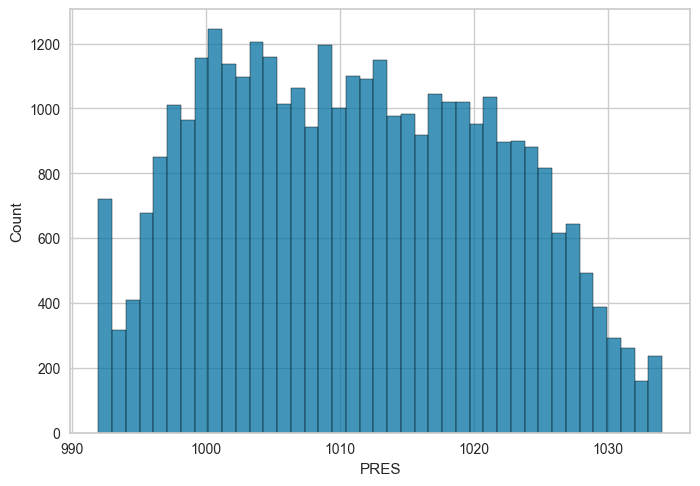

In [25]:
sns.histplot(prsa_data.PRES)

<Axes: >

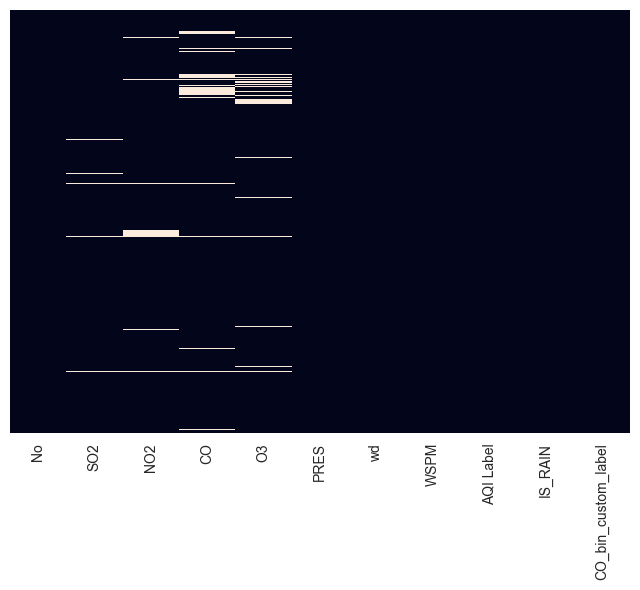

In [26]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [27]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 884, dtype: int64

In [28]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

<Axes: >

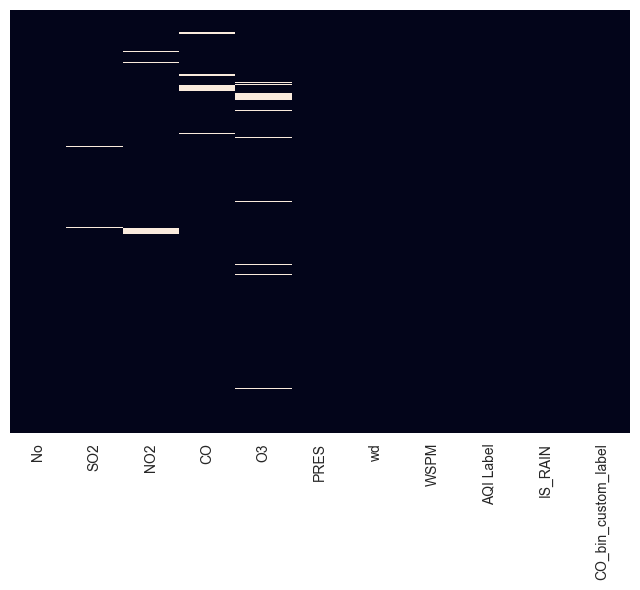

In [29]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [30]:
prsa_data.isnull().sum()

No                        0
SO2                     281
NO2                     702
CO                     1028
O3                     1300
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

In [31]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())

In [32]:
filler = prsa_data.O3[prsa_data.O3.isna()]

In [33]:
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)

In [34]:
prsa_data.O3 = prsa_data.O3.fillna(filler)

In [35]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,6.000000,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.000000,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,1011.055986,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,5,9.000000,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,6,8.000000,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


In [36]:
prsa_data.SO2 = np.log(prsa_data.SO2)

## Практическая работа

### 1. Другие методы визуализации

Медиана давления около центральной линии, половина значений лежит в пределах коробки (IQR), “усы” показывают диапазон данных без выбросов по правилу 1.5 IQR

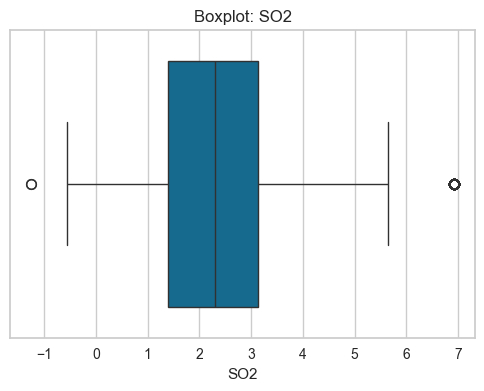

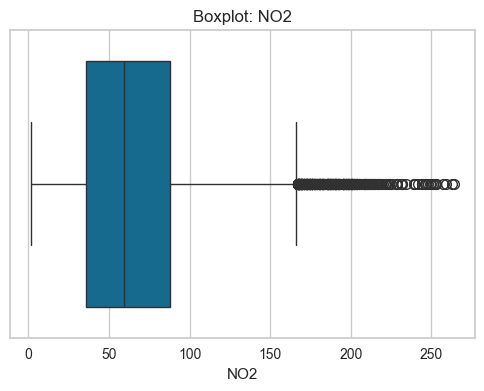

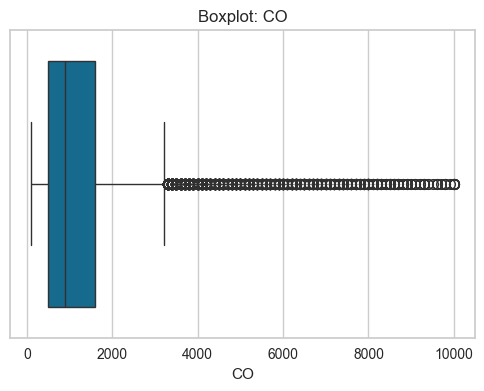

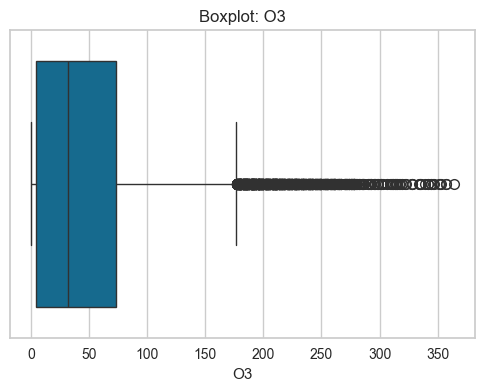

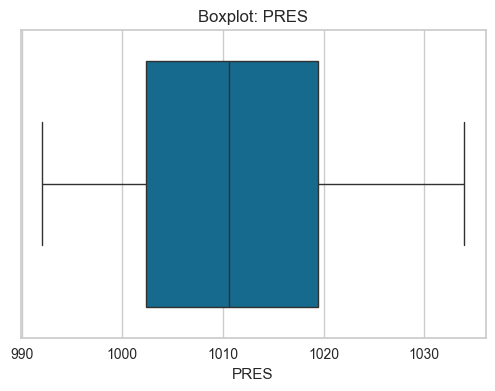

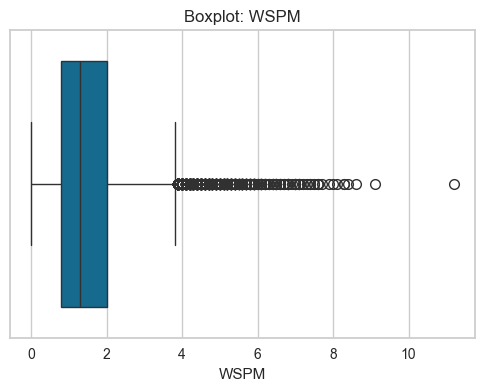

In [37]:
num_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=prsa_data[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

Распределение SO₂ сосредоточено в диапазоне 1–4 с максимумом около низких значений, имеет правостороннюю асимметрию и редкие высокие значения до ~7, что указывает на наличие выбросов или экстремальных наблюдений.

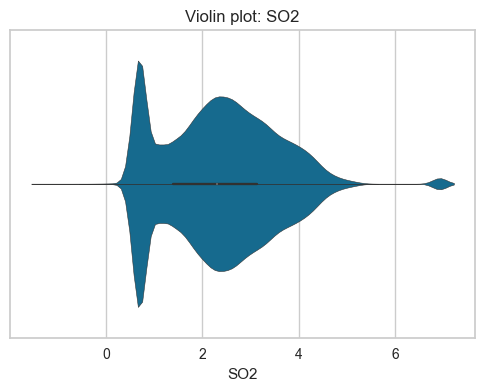

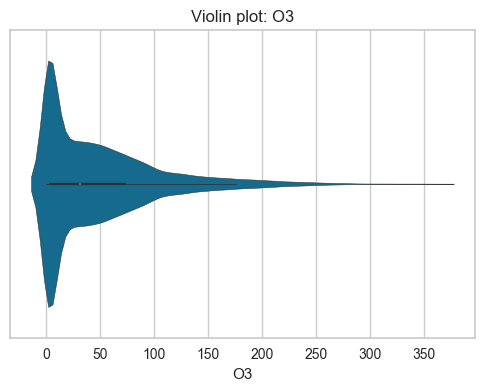

In [38]:
for col in ['SO2', 'O3']:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x=prsa_data[col])
    plt.title(f'Violin plot: {col}')
    plt.show()

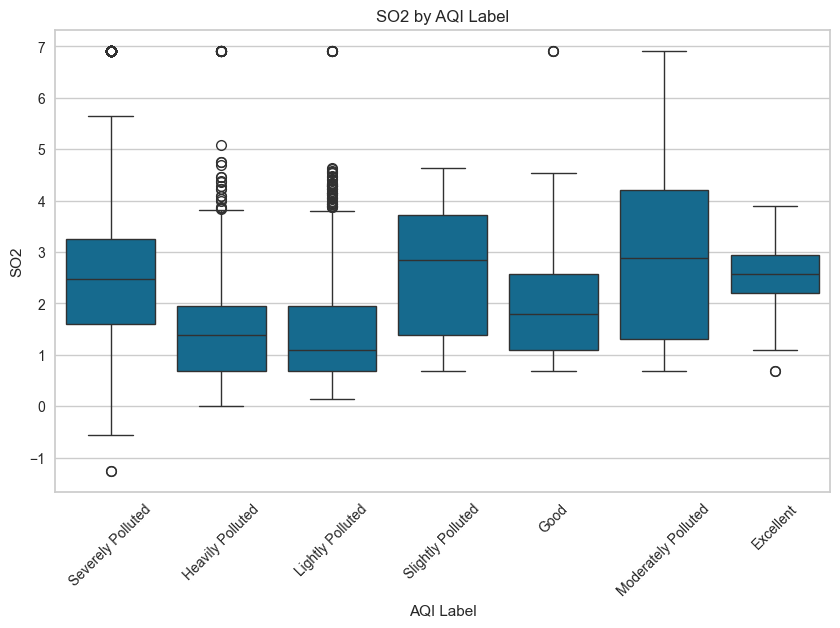

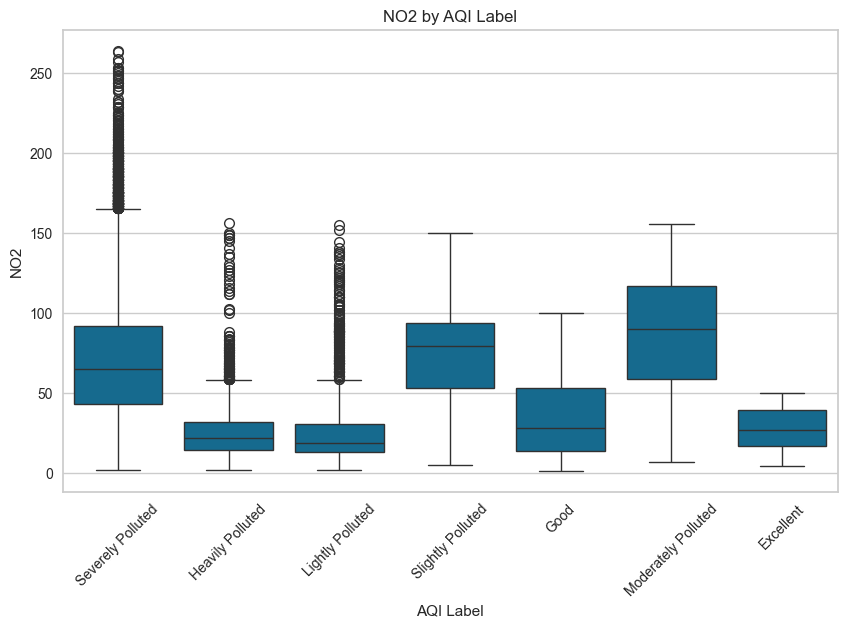

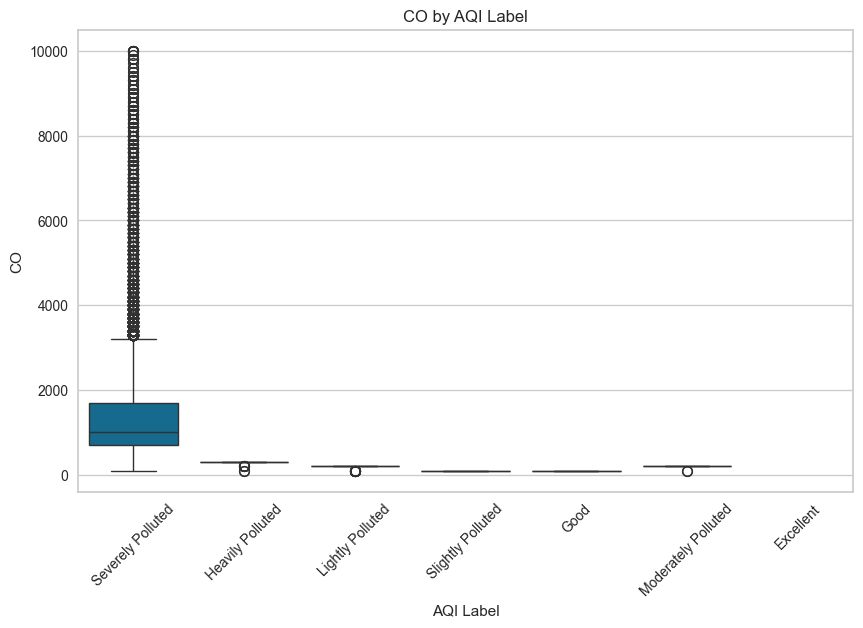

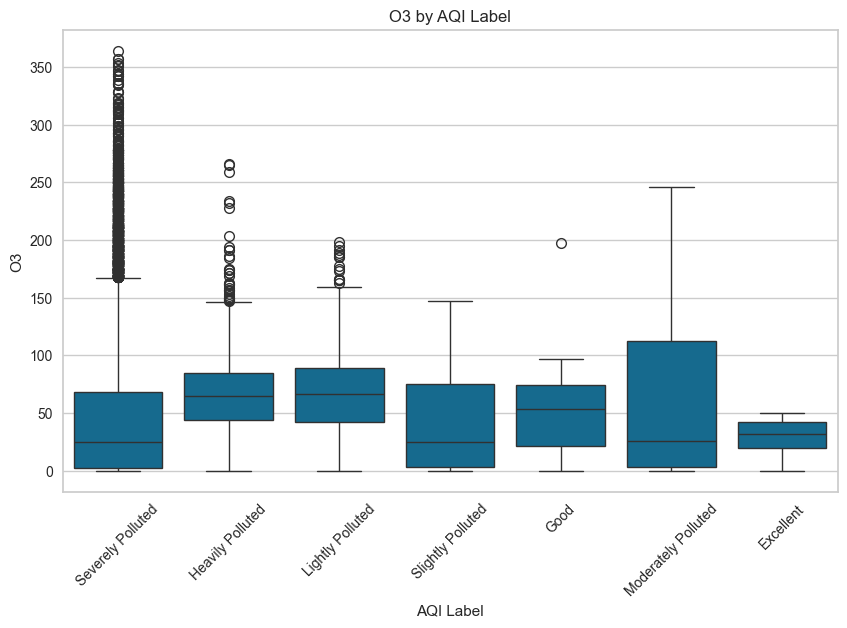

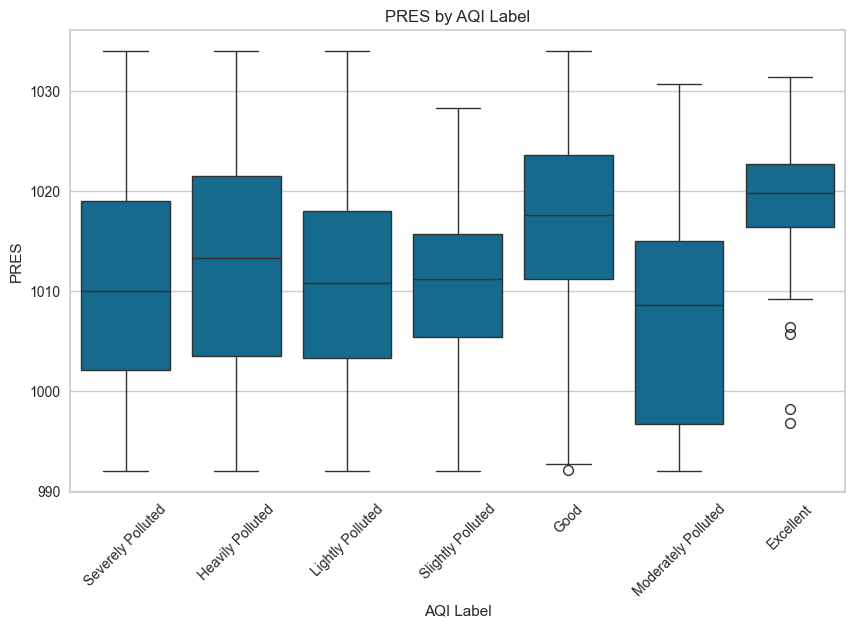

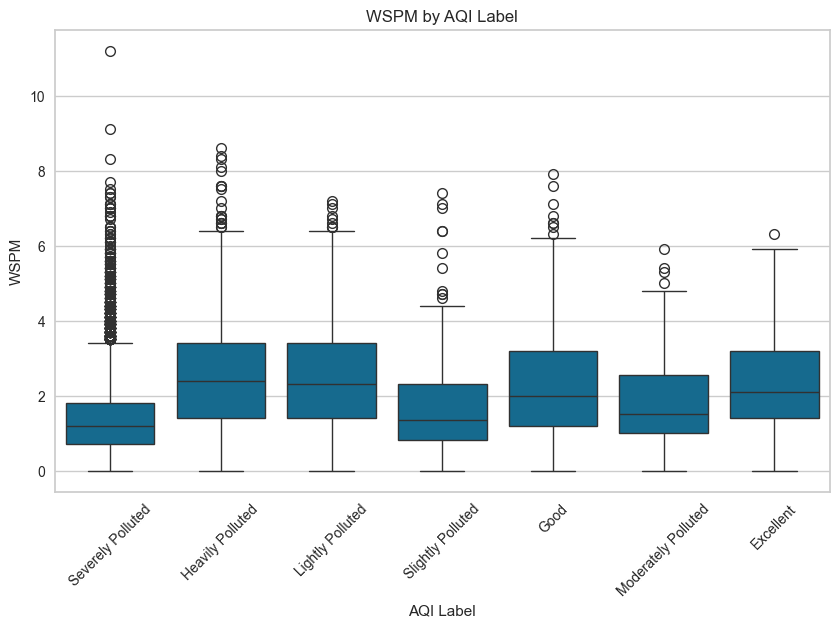

In [39]:
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=prsa_data, x='AQI Label', y=col)
    plt.title(f'{col} by AQI Label')
    plt.xticks(rotation=45)
    plt.show()

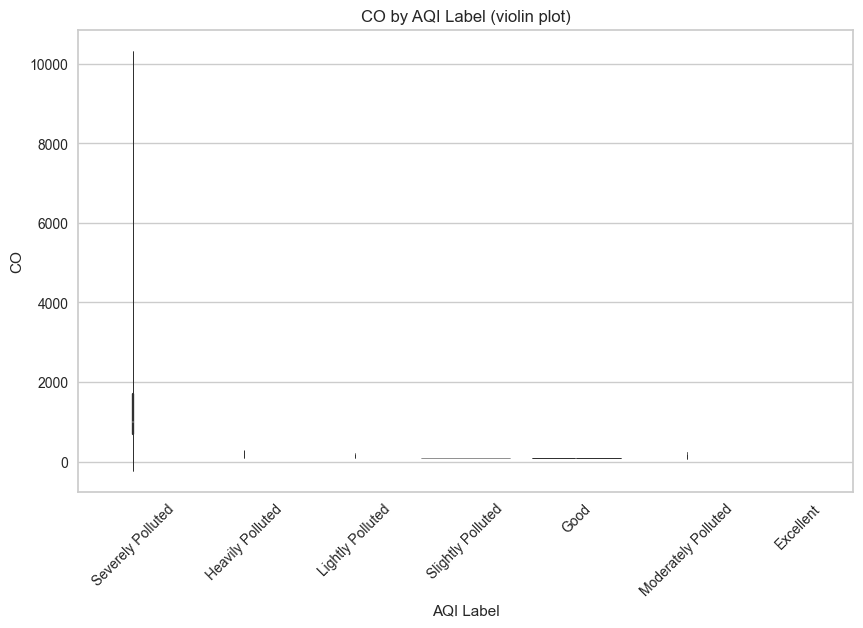

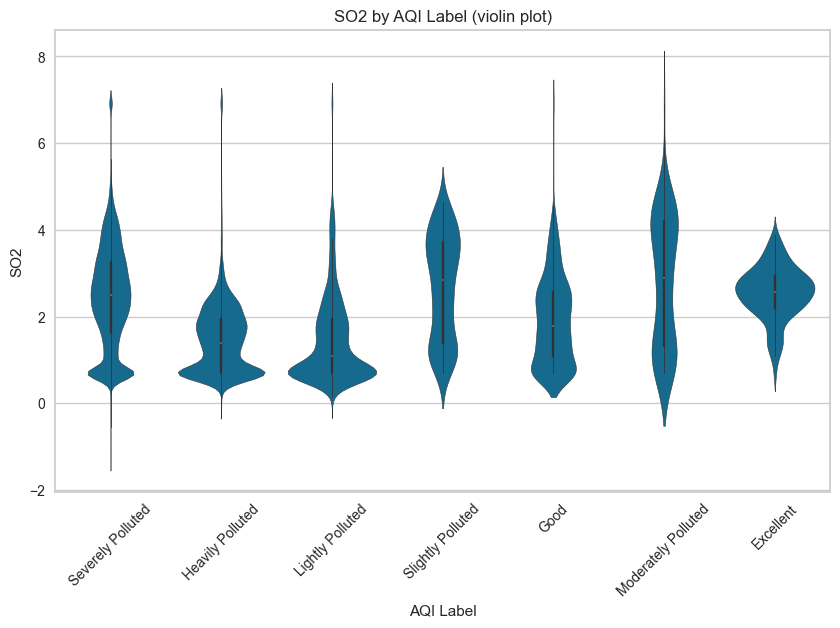

In [40]:
for col in ['CO', 'SO2']:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=prsa_data, x='AQI Label', y=col)
    plt.title(f'{col} by AQI Label (violin plot)')
    plt.xticks(rotation=45)
    plt.show()

### 2. Адаптивный клиппинг через процентили

In [42]:
lower_percentile = 1
upper_percentile = 99

In [43]:
for col in ['PRES', 'SO2', 'NO2', 'CO', 'O3', 'WSPM']:
    lower_bound = prsa_data[col].quantile(lower_percentile / 100)
    upper_bound = prsa_data[col].quantile(upper_percentile / 100)
    
    prsa_data[col] = prsa_data[col].clip(lower=lower_bound, upper=upper_bound)
    
    print(f"{col}: lower={lower_bound:.2f}, upper={upper_bound:.2f}")

PRES: lower=992.00, upper=1032.00
SO2: lower=0.69, upper=5.08
NO2: lower=7.00, upper=176.00
CO: lower=100.00, upper=6500.00
O3: lower=1.00, upper=236.00
WSPM: lower=0.00, upper=5.20


### 4. Нормализация численных признаков

StandardScaler выполняет стандартизацию данных, приводя их к нулевому среднему и единичному стандартному отклонению, хорошо подходит для “чистых” данных, но чувствителен к выбросам; MinMaxScaler нормализует значения в заданный диапазон (обычно [0,1]), удобен для моделей, где важен фиксированный масштаб, однако сильно зависит от выбросов; RobustScaler использует медиану и межквартильный размах (IQR), благодаря чему устойчив к выбросам и лучше работает на данных с аномальными значениями.

In [53]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [49]:
numeric_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']

In [45]:
prsa_data_norm = prsa_data.copy()

In [58]:
prsa_data_norm['PRES_scaled'] = StandardScaler().fit_transform(prsa_data_norm[['PRES']])

In [59]:
prsa_data_norm['WSPM_scaled'] = MinMaxScaler().fit_transform(prsa_data_norm[['WSPM']])

In [54]:
scaler_robust = RobustScaler()
for col in ['SO2', 'NO2', 'CO', 'O3']:
    prsa_data_norm[f'{col}_scaled'] = scaler_robust.fit_transform(prsa_data_norm[[col]])

In [55]:
print(prsa_data[numeric_cols].describe().round(2))

            SO2       NO2        CO        O3      PRES      WSPM
count  34180.00  33478.00  33152.00  34180.00  34180.00  34180.00
mean       2.32     64.80   1308.76     48.56   1011.04      1.50
std        1.15     37.24   1216.72     53.95     10.30      1.08
min        0.69      7.00    100.00      1.00    992.00      0.00
25%        1.39     36.00    500.00      4.00   1002.40      0.80
50%        2.30     59.00    900.00     32.00   1010.60      1.30
75%        3.14     88.00   1600.00     73.00   1019.40      2.00
max        5.08    176.00   6500.00    236.00   1032.00      5.20


In [56]:
scaled_cols = [f'{col}_scaled' for col in numeric_cols]
print(prsa_data_norm[scaled_cols].describe().round(2))

       SO2_scaled  NO2_scaled  CO_scaled  O3_scaled  PRES_scaled  WSPM_scaled
count    34180.00    33478.00   33152.00   34180.00     34180.00     34180.00
mean         0.01        0.11       0.37       0.24        -0.00         0.29
std          0.66        0.72       1.11       0.78         1.00         0.21
min         -0.92       -1.00      -0.73      -0.45        -1.85         0.00
25%         -0.52       -0.44      -0.36      -0.41        -0.84         0.15
50%          0.00        0.00       0.00       0.00        -0.04         0.25
75%          0.48        0.56       0.64       0.59         0.81         0.38
max          1.59        2.25       5.09       2.96         2.03         1.00


### 3. Пропуски

In [60]:
print(prsa_data_norm.isnull().sum())

No                        0
SO2                       0
NO2                     702
CO                     1028
O3                        0
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
PRES_scaled               0
WSPM_scaled               0
SO2_scaled                0
NO2_scaled              702
CO_scaled              1028
O3_scaled                 0
dtype: int64


In [62]:
for col in ['SO2', 'NO2', 'CO', 'O3']:
    median_val = prsa_data_norm[col].median()
    prsa_data_norm[col].fillna(median_val, inplace=True)

In [64]:
prsa_data_norm['PRES'].fillna(prsa_data_norm['PRES'].mean(), inplace=True)
prsa_data_norm['WSPM'].fillna(prsa_data_norm['WSPM'].mean(), inplace=True)

In [65]:
print(prsa_data_norm.isnull().sum())

No                     0
SO2                    0
NO2                    0
CO                     0
O3                     0
PRES                   0
wd                     0
WSPM                   0
AQI Label              0
IS_RAIN                0
CO_bin_custom_label    0
PRES_scaled            0
WSPM_scaled            0
SO2_scaled             0
NO2_scaled             0
CO_scaled              0
O3_scaled              0
dtype: int64


### 5. Кореллограмма по всем численным столбцам датасета

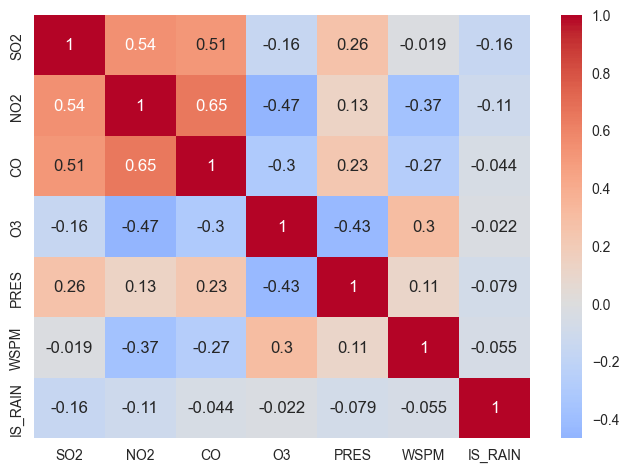

In [66]:
corr_matrix = prsa_data_norm[['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM', 'IS_RAIN']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

### 6. Связи между признаками

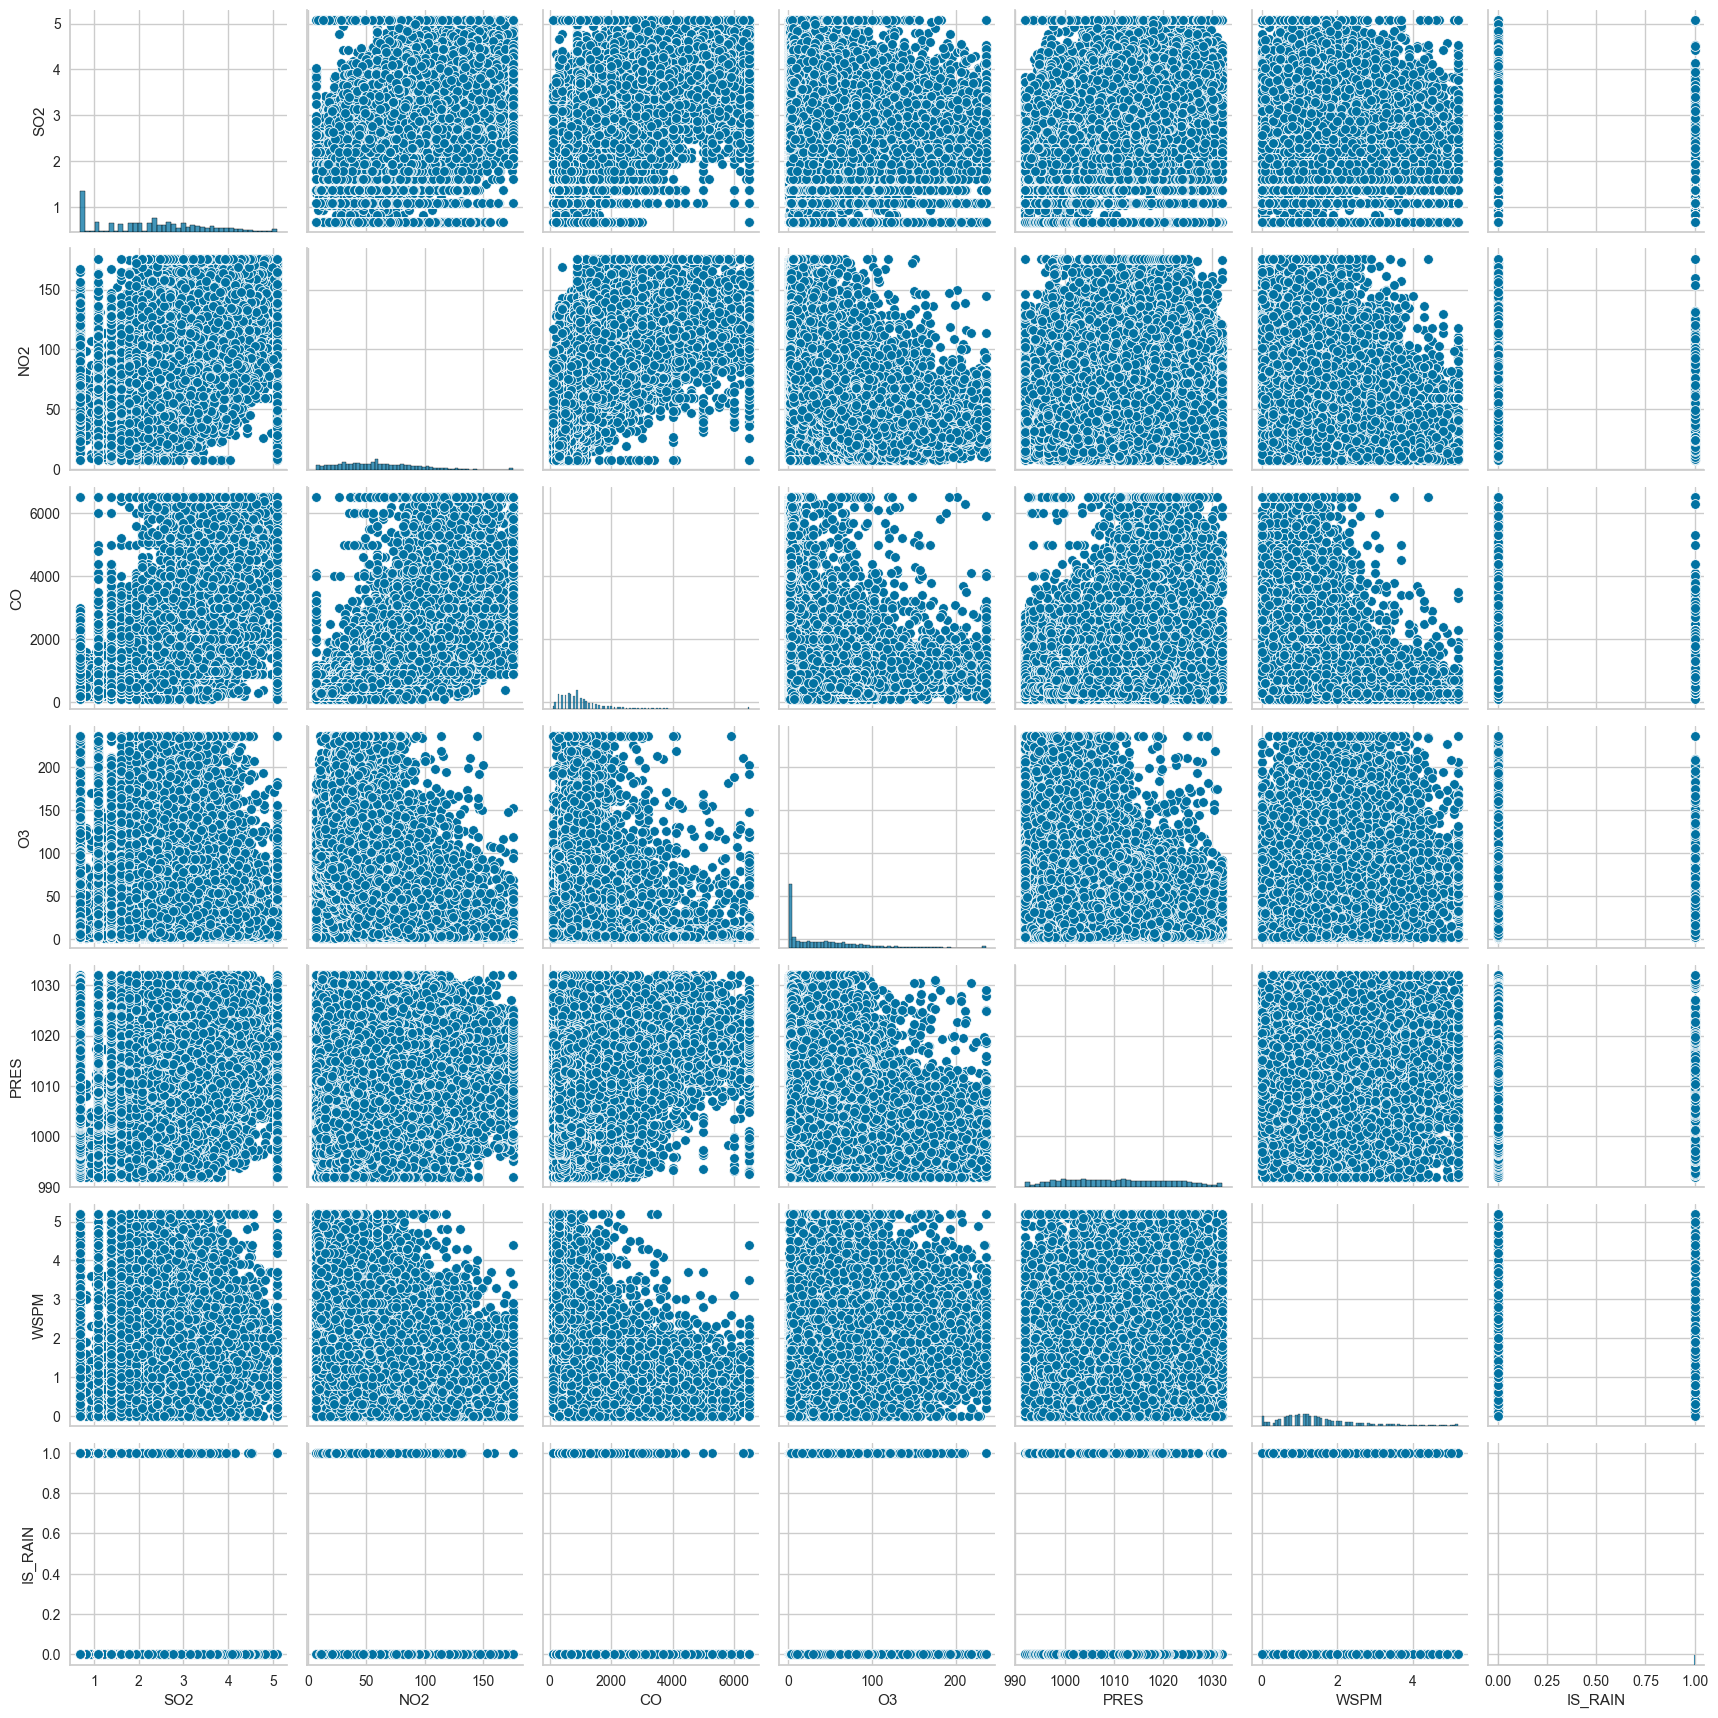

In [67]:
sns.pairplot(prsa_data_norm[['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM', 'IS_RAIN']])
plt.show()